In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [69]:
RAW_PATH = Path("../data/raw/dataset_full.csv")     
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RAW_PATH)
print(df.shape)
df.head()

(88647, 112)


,qty_dot_url,qty_hyphen_url,qty_underline_url,qty_slash_url,qty_questionmark_url,qty_equal_url,qty_at_url,qty_and_url,qty_exclamation_url,qty_space_url,...,qty_ip_resolved,qty_nameservers,qty_mx_servers,ttl_hostname,tls_ssl_certificate,qty_redirects,url_google_index,domain_google_index,url_shortened,phishing
0,3,0,0,1,0,0,0,0,0,0,...,1,2,0,892,0,0,0,0,0,1
1,5,0,1,3,0,3,0,2,0,0,...,1,2,1,9540,1,0,0,0,0,1
2,2,0,0,1,0,0,0,0,0,0,...,1,2,3,589,1,0,0,0,0,0
3,4,0,2,5,0,0,0,0,0,0,...,1,2,0,292,1,0,0,0,0,1
4,2,0,0,0,0,0,0,0,0,0,...,1,2,1,3597,0,1,0,0,0,0


In [70]:
df['phishing'].value_counts()

phishing
0    58000
1    30647
Name: count, dtype: int64

In [53]:
print("Missing values:\n", df.isnull().values.any())
print("\nDuplicates:", df.duplicated().sum())
df.info()

Missing values:
 False

Duplicates: 1438
<class 'pandas.DataFrame'>
RangeIndex: 88647 entries, 0 to 88646
Columns: 112 entries, qty_dot_url to phishing
dtypes: float64(1), int64(111)
memory usage: 75.7 MB


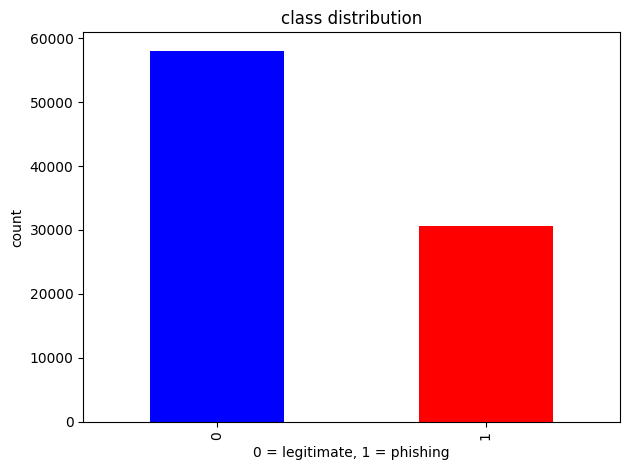

In [45]:
ax = df['phishing'].value_counts().plot(kind='bar', color=['blue', 'red'])
ax.set_title("class distribution")
ax.set_xlabel("0 = legitimate, 1 = phishing")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

In [46]:
# do we need to use encoding? (is there any categorical features?)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print(f"The number of categorical columns is: {len(categorical_cols)}")

The number of categorical columns is: 0


In [71]:
duplicates = df[df.duplicated()]
duplicates

,qty_dot_url,qty_hyphen_url,qty_underline_url,qty_slash_url,qty_questionmark_url,qty_equal_url,qty_at_url,qty_and_url,qty_exclamation_url,qty_space_url,...,qty_ip_resolved,qty_nameservers,qty_mx_servers,ttl_hostname,tls_ssl_certificate,qty_redirects,url_google_index,domain_google_index,url_shortened,phishing
596,2,0,0,0,0,0,0,0,0,0,...,-1,2,0,-1,0,-1,0,0,0,0
1267,2,0,0,0,0,0,0,0,0,0,...,-1,2,0,-1,0,-1,0,0,0,0
2614,2,0,0,0,0,0,0,0,0,0,...,-1,4,0,-1,0,-1,0,0,0,0
3214,3,2,0,6,1,3,0,2,0,0,...,-1,4,0,-1,0,-1,0,0,0,1
3548,2,0,1,2,0,0,0,0,0,0,...,-1,4,0,-1,0,-1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88363,2,0,0,0,0,0,0,0,0,0,...,-1,2,1,-1,0,-1,0,0,0,0
88365,2,0,0,0,0,0,0,0,0,0,...,-1,0,0,-1,0,-1,-1,-1,0,0
88387,2,1,0,6,1,3,0,2,0,0,...,-1,4,0,-1,0,-1,0,0,0,1
88405,2,0,0,0,0,0,0,0,0,0,...,-1,4,0,-1,0,-1,0,0,0,0


In [72]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [73]:
df['phishing'].value_counts()

phishing
0    56712
1    30497
Name: count, dtype: int64

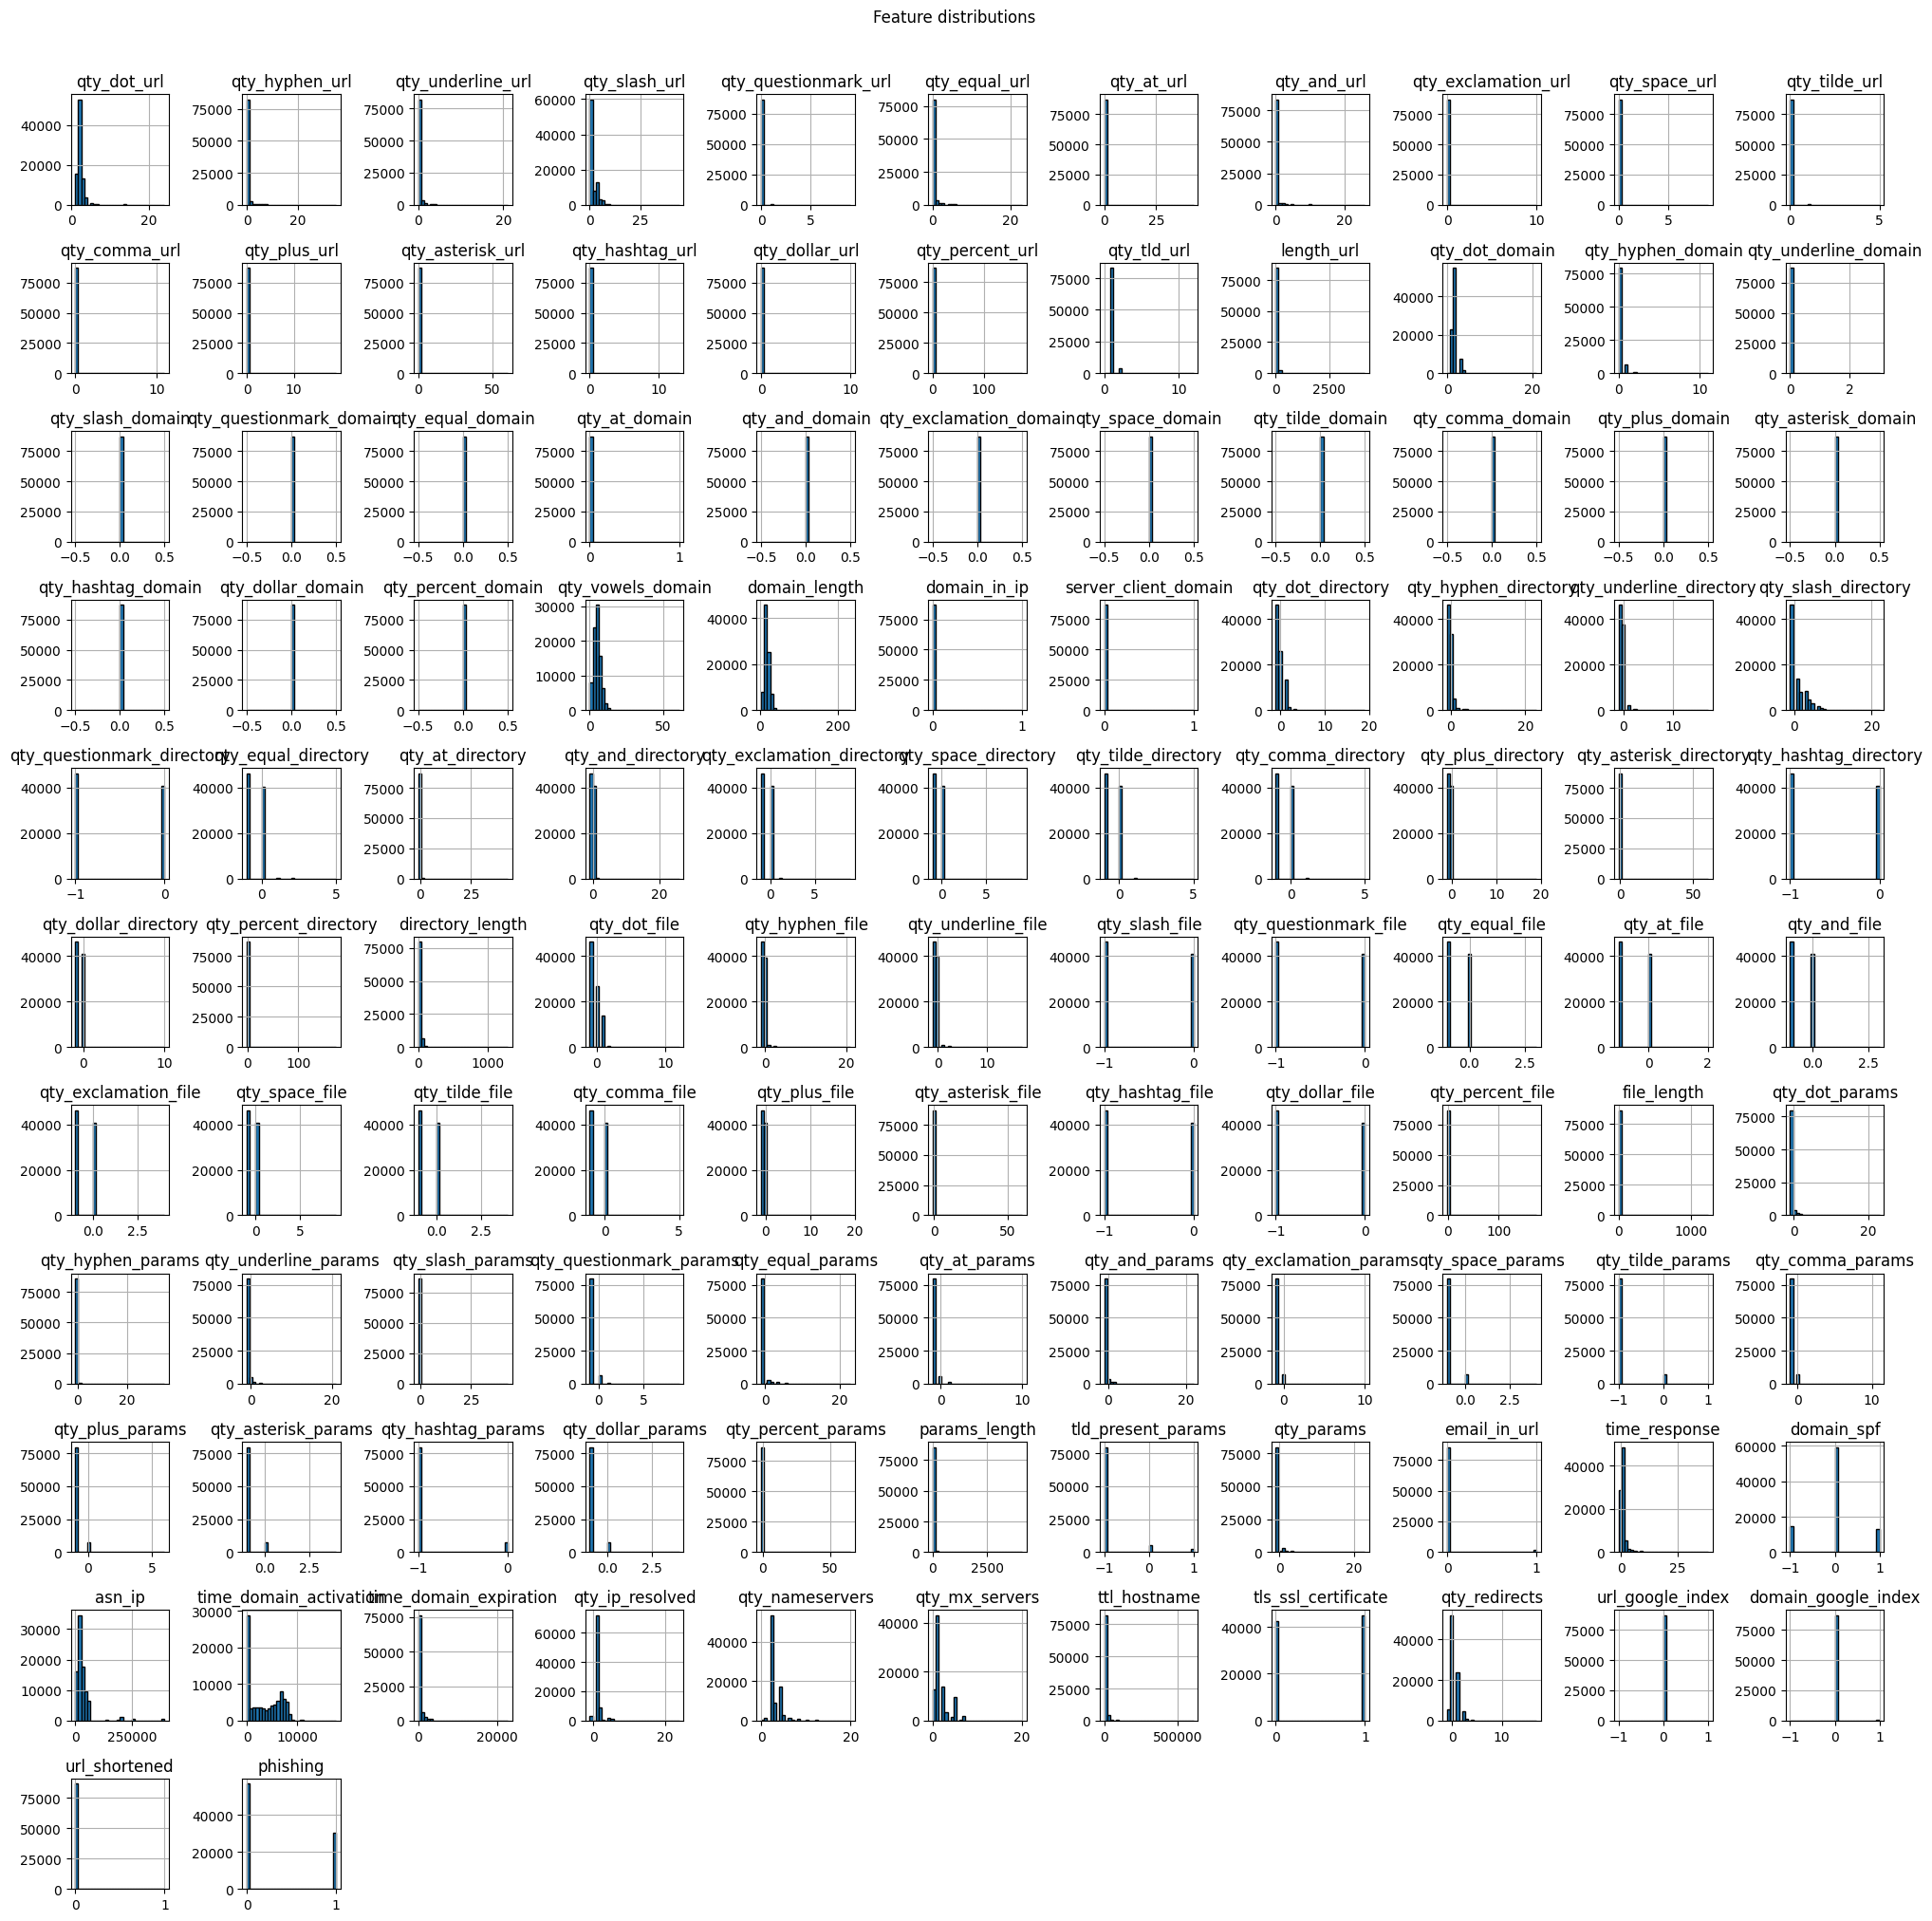

In [16]:
df.hist(figsize=(20, 20), bins=30, edgecolor='black')
plt.suptitle("Feature distributions", y=1.01)
plt.tight_layout()
plt.show()

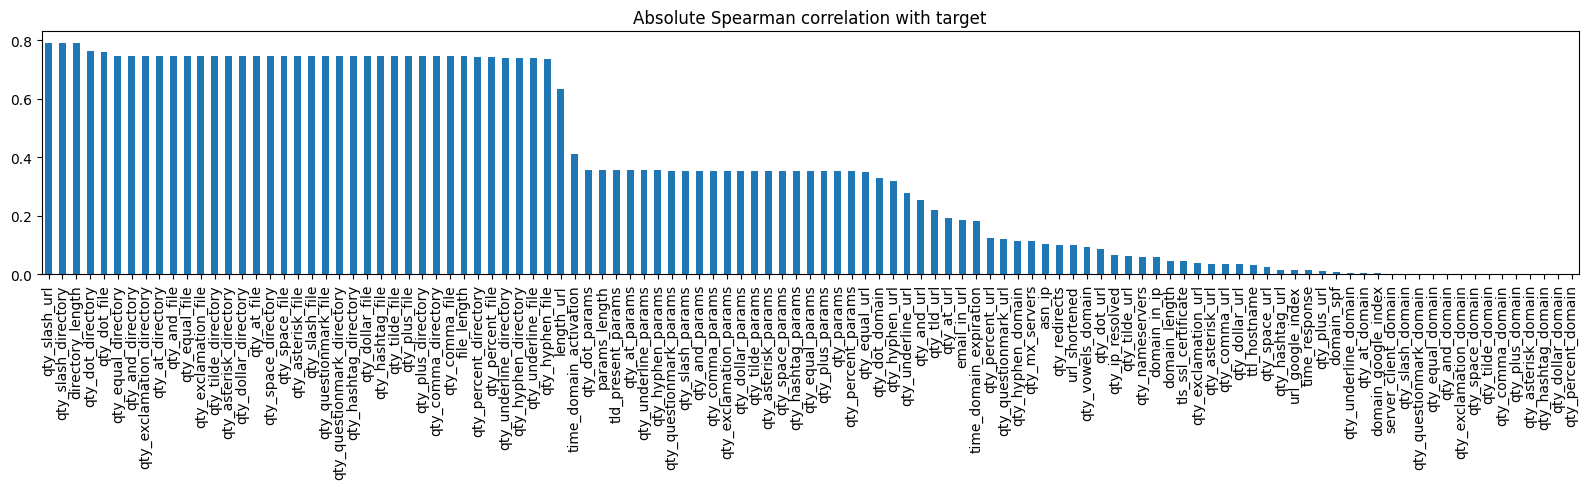

In [17]:
target_corr = df.corr(method='spearman')['phishing'].drop('phishing').abs().sort_values(ascending=False)
target_corr.plot(kind='bar', figsize=(16, 5), title="Absolute Spearman correlation with target")
plt.tight_layout()
plt.show()

In [66]:
from feature_engine.selection import DropConstantFeatures

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

constant_feature_remover = DropConstantFeatures(tol=1, variables=None)
X = constant_feature_remover.fit_transform(X)
print(f"Number of constant features: {len(constant_feature_remover.features_to_drop_)}")

quasi_constant_feature_remover = DropConstantFeatures(tol=0.99, variables=None)
X = quasi_constant_feature_remover.fit_transform(X)
print(f"Number of quasi-constant features: {len(quasi_constant_feature_remover.features_to_drop_)}")

Number of constant features: 13
Number of quasi-constant features: 16


In [67]:
df = pd.concat([X, y], axis=1)
print("New dataset shape:", df.shape)

New dataset shape: (87209, 83)


## Multicollinearity

Reference: <a href="https://medium.com/@saba_fatima/multicollinearity-in-machine-learning-understanding-the-challenge-and-solutions-741e9212af29" >Multicollinearity in Machine Learning: Understanding the Challenge and Solutions</a>

### Correlated Features in the Dataset

Our main reference paper **"A high-accuracy phishing website detection method based on machine learning"** did **not mention removing corr features**

Here is our intuition about why strong correlations appear in the dataset

---

### Example URL

```
https://www.example.com/path/file.html?param=value
```

Feature definitions:

```
qty_dot_url        = number of dots in the entire URL       (e.g., 4)
qty_dot_domain     = number of dots in the domain only      (e.g., 2)
qty_dot_directory  = number of dots in the path only        (e.g., 1)
qty_dot_file       = number of dots in the filename only    (e.g., 1)
```

so we can conclude that

```
qty_dot_url = qty_dot_domain + qty_dot_directory + qty_dot_file
```

therefore the _url version of a feature will always be highly correlated with its _domain, _directory, and _file


because:
- each qty_* feature is repeated across 4 different URL parts
- there are 15+ character types

This result in large number of correlated features leading to a **correlation explosion**

---

### Impact of Multicollinearity on Different Models

| Model | Affected by Multicollinearity? | Impact |
|------|------|------|
| Logistic Regression | Severe | coefficients become unstable |
| SVM | Yes | Can make performance worse |
| Random Forest | Mid | feature importance solve the problem |
| XGBoost / GBM | Minimal | tree boosting handle correlation well |
| Neural Networks | Mid | Regularization usually mitigate the issue |

---

### We will do the following to address multico. in our dataset

#### If using Regression / SVM
- apply correlation filtering with threshold 0.9
- use target-correlation tiebreaker

#### If using Random Forest / XGBoost
- skip correlation filtering 


In [20]:

def features_to_drop(method: str, threshold: float) -> int: 
    # 1. Compute Spearman correlation (no target column)
    corr_matrix = df.drop(columns=['phishing']).corr(method=method).abs()

    # 2. Upper triangle mask
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    # 3. For each correlated pair, keep the one more correlated with label
    target_corr = df.corr(method=method)['phishing'].abs()

    to_drop = []
    for col in upper.columns:
        correlated_with = upper.index[upper[col] > threshold].tolist()
        for partner in correlated_with:
            # Drop whichever has lower target correlation
            if target_corr[col] >= target_corr[partner]:
                to_drop.append(partner)
            else:
                to_drop.append(col)

    to_drop = list(set(to_drop))
    return to_drop

print(f"Number of correlated features to drop (using Pearson): {len(features_to_drop("pearson", threshold=0.90))}")
print(f"Number of correlated features to drop (using Spearman): {len(features_to_drop("spearman", threshold=0.90))}")

Number of correlated features to drop (using Pearson): 42
Number of correlated features to drop (using Spearman): 57


## Handling Outliers 

In [21]:
def get_top_k_features_with_most_outliers(df, k=5):
    numeric_df = df.select_dtypes(include=[np.number])

    outlier_counts = {}

    for column in numeric_df.columns:
        Q1 = numeric_df[column].quantile(0.25)
        Q3 = numeric_df[column].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = numeric_df[(numeric_df[column] < lower_bound) | (numeric_df[column] > upper_bound)]
        outlier_counts[column] = len(outliers)

    sorted_outliers = sorted(outlier_counts.items(), key=lambda x: x[1], reverse=True)

    print("Top k Features with the most Outliers:")
    for feature, count in sorted_outliers[:k]:
        print(f"{feature}: {count} outliers found")
    return sorted_outliers[:k]

Top k Features with the most Outliers:
qty_dot_url: 34486 outliers found
domain_spf: 27763 outliers found
file_length: 21288 outliers found
qty_ip_resolved: 15452 outliers found
qty_hyphen_url: 15384 outliers found


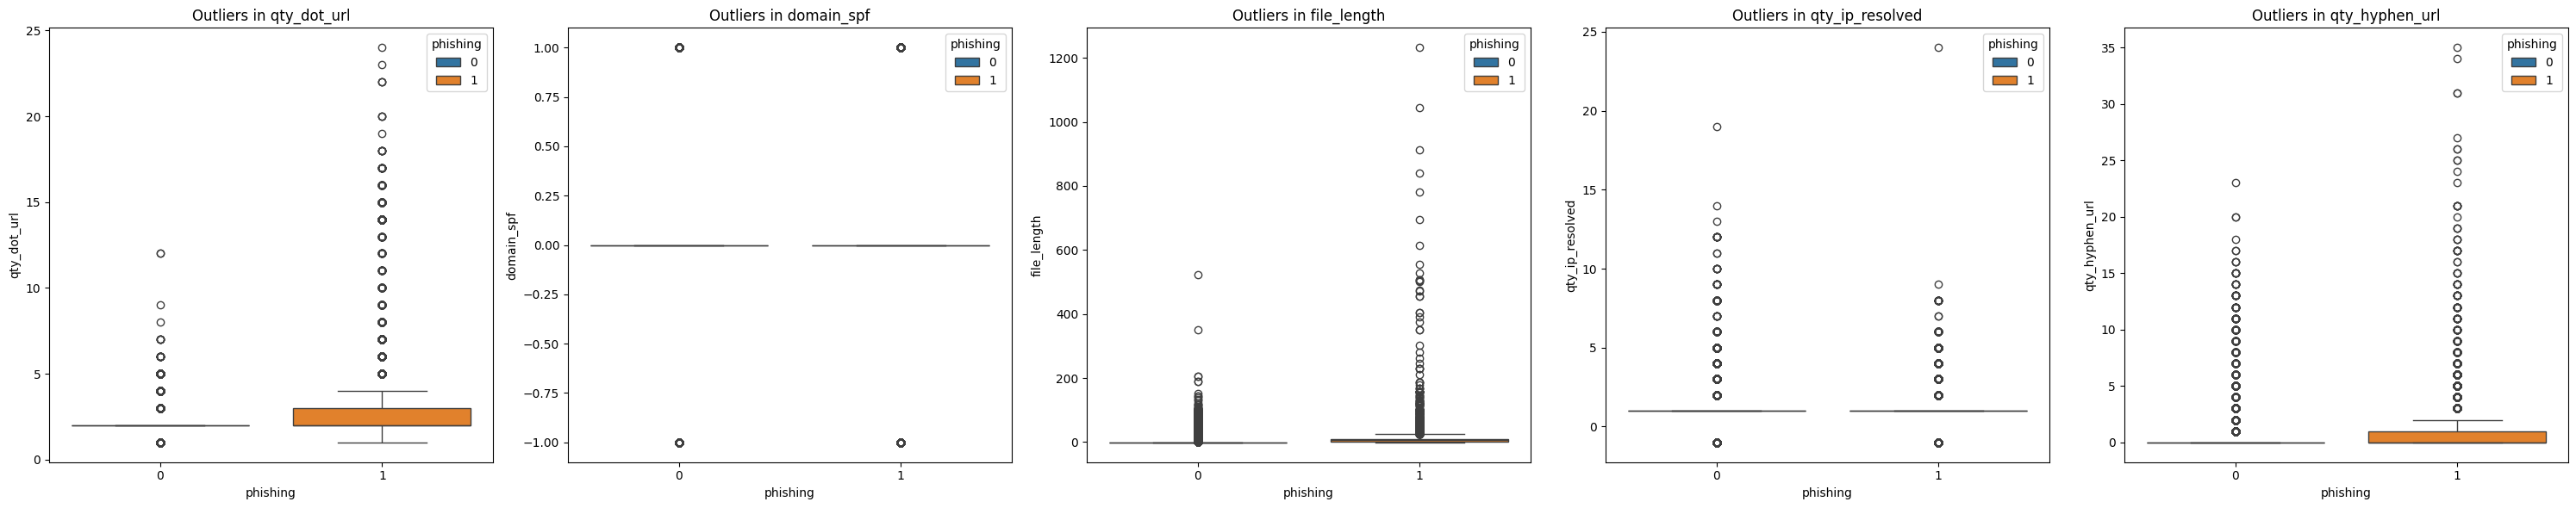

In [22]:
k = 5
features_with_outliers = get_top_k_features_with_most_outliers(df, k=k)
features_with_outliers = [name for name, _ in features_with_outliers]

fig, axes = plt.subplots(1, k, figsize=(6*k, 6))

for i, feature in enumerate(features_with_outliers):
    sns.boxplot(
        ax=axes[i],
        x='phishing',
        y=feature,
        hue='phishing',
        data=df
    )
    axes[i].set_title(f'Outliers in {feature}')

plt.tight_layout()
plt.show()


With ~88k samples having thousands of outliers means these features strongly differentiate phishing from legitimate sites <br/>
In cybersecurity ML these outliers are valuable signals not noise <br/>

<br/>

<details>
<summary><b>domain_spf</b></summary>
<p>
    Sender Policy Framework. This is a security record. Phishing sites often have "broken" or missing SPF records because they are hosted on temporary, cheap servers. 
</p>
</details>
<details>
<summary><b>qty_hyphen_url</b></summary>
<p>
    Quantity of Hyphens. Attackers love hyphens to mimic real brands (e.g., secure-login-bank.com). A normal URL has 0-1 hyphens. 
</p>
</details>
<details>
<summary><b>qty_ip_resolved</b></summary>
<p>
   IP Resolution. Legitimate sites usually resolve to one or two stable IPs. Phishing sites often resolve to many IPs (using fast-flux techniques) or hide behind complex proxies
</p>
</details>
<details>
<summary><b>qty_dot_url</b></summary>
<p>
   Number of dots in the full url
</p>
</details>
<details>
<summary><b>file_length</b></summary>
<p>
    the length of the file segment in the url
</p>
</details>




## ZeroR Classifier (baseline performance)

In [23]:
majority_class = df['phishing'].mode()[0]
baseline_accuracy = df['phishing'].value_counts(normalize=True).max()
print(f"Majority class: {majority_class} (0=Legitimate, 1=Phishing)")
print(f"ZeroR Accuracy: {baseline_accuracy:.4f}")

Majority class: 0 (0=Legitimate, 1=Phishing)
ZeroR Accuracy: 0.6503


## Our Scenarios for Logistic Regression and SVM

|Scenario|PCA|Correlation Filtering|SMOTE|
|-----|------|-------|-------|
|S1|0|0|0|
|S2|0|0|1|
|S3|0|1|0|
|S4|0|1|1|
|S5|1|0|0|
|S6|1|0|1|

## Our Scenarios for Random Forest and XGBoost
|Scenario|SMOTE|
|------|--------|
|S1|0|
|S2|1|


In [68]:
SAVE_PATH = PROCESSED_DIR / "cleaned.csv"
df.to_csv(SAVE_PATH, index=False)

In [59]:
clean = pd.read_csv("../data/processed/cleaned.csv")

In [60]:
clean.shape

(87209, 99)

In [61]:
clean.columns

Index(['qty_dot_url', 'qty_hyphen_url', 'qty_underline_url', 'qty_slash_url',
       'qty_questionmark_url', 'qty_equal_url', 'qty_at_url', 'qty_and_url',
       'qty_exclamation_url', 'qty_space_url', 'qty_tilde_url',
       'qty_comma_url', 'qty_plus_url', 'qty_asterisk_url', 'qty_hashtag_url',
       'qty_dollar_url', 'qty_percent_url', 'qty_tld_url', 'length_url',
       'qty_dot_domain', 'qty_hyphen_domain', 'qty_underline_domain',
       'qty_at_domain', 'qty_vowels_domain', 'domain_length', 'domain_in_ip',
       'server_client_domain', 'qty_dot_directory', 'qty_hyphen_directory',
       'qty_underline_directory', 'qty_slash_directory',
       'qty_questionmark_directory', 'qty_equal_directory', 'qty_at_directory',
       'qty_and_directory', 'qty_exclamation_directory', 'qty_space_directory',
       'qty_tilde_directory', 'qty_comma_directory', 'qty_plus_directory',
       'qty_asterisk_directory', 'qty_hashtag_directory',
       'qty_dollar_directory', 'qty_percent_directory',

In [62]:
print(len(clean.columns))

99


In [42]:
# Run in your training notebook or as a standalone script in PURE-ML

import pandas as pd
import json
from pathlib import Path

df = pd.read_csv("../data/processed/cleaned.csv")

dynamic_features = [
    'time_response', 'domain_spf', 'asn_ip',
    'time_domain_activation', 'time_domain_expiration',
    'qty_ip_resolved', 'qty_nameservers', 'qty_mx_servers',
    'ttl_hostname', 'tls_ssl_certificate', 'qty_redirects'
]

# Separate medians for phishing and legitimate
# We use overall median for imputation
medians = {}
for feat in dynamic_features:
    col = df[feat].replace(-1, pd.NA)   # treat -1 as missing
    medians[feat] = float(col.median())

print("Medians:")
for k, v in medians.items():
    print(f"  {k}: {v}")

Path("data/processed").mkdir(parents=True, exist_ok=True)
with open("data/processed/feature_medians.json", "w") as f:
    json.dump(medians, f, indent=2)

print("\nSaved → data/processed/feature_medians.json")

Medians:
  time_response: 0.5031869999999999
  domain_spf: 0.0
  asn_ip: 22612.0
  time_domain_activation: 5189.0
  time_domain_expiration: 281.0
  qty_ip_resolved: 1.0
  qty_nameservers: 2.0
  qty_mx_servers: 1.0
  ttl_hostname: 3440.0
  tls_ssl_certificate: 1.0
  qty_redirects: 0.0

Saved → data/processed/feature_medians.json
